## Notebook

In [1]:
%matplotlib inline

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from collections import defaultdict
import ccf_streamlines.projection as ccfproj
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from itertools import combinations

import lc_reconstruction_analysis.utils as utils
import lc_reconstruction_analysis.clustering as clustering

## Functions for loading CCF structures

In [2]:
def load_obj(filename):
    """
    Load the vertices, vertex normals, and indices from a .obj file.

    Parameters:
    filename (str): Path to the .obj file

    Returns:
    tuple: A tuple containing three elements:
        - vertices (list of tuples): List of vertices, each vertex is a tuple (x, y, z)
        - normals (list of tuples): List of vertex normals, each normal is a tuple (nx, ny, nz)
        - indices (list of tuples): List of indices, each index is a tuple of vertex indices defining a face
    """
    vertices = []
    normals = []
    indices = []

    with open(filename, 'r') as file:
        for line in file:
            if line.startswith('v '):  # Vertex definition
                parts = line.split()
                vertices.append((float(parts[1]), float(parts[2]), float(parts[3])))
            elif line.startswith('vn '):  # Vertex normal definition
                parts = line.split()
                normals.append((float(parts[1]), float(parts[2]), float(parts[3])))
            elif line.startswith('f '):  # Face definition
                parts = line.split()
                # Extracting only the vertex indices (ignoring texture and normal indices)
                face_indices = [int(p.split('/')[0]) - 1 for p in parts[1:]]
                indices.append(tuple(face_indices))

    return vertices, normals, indices


def compute_mesh_volume(vertices, indices):
    volume = 0.0
    for tri in indices:  # Each `tri` is a list of 3 indices
        v1 = np.array(vertices[tri[0]])
        v2 = np.array(vertices[tri[1]])
        v3 = np.array(vertices[tri[2]])
        
        # Compute the signed volume of the tetrahedron
        tetra_volume = np.dot(v1, np.cross(v2, v3)) / 6.0
        volume += tetra_volume

    return abs(volume)  # Take absolute value to ensure positive volume

def compute_mesh_centroid(vertices, indices):
    # Convert inputs to numpy arrays if they aren't already
    vertices = np.array(vertices, dtype=float)
    indices = np.array(indices, dtype=int)

    total_area = 0.0
    weighted_centroid = np.zeros(3)

    for tri in indices:
        v0, v1, v2 = vertices[tri[0]], vertices[tri[1]], vertices[tri[2]]

        tri_centroid = (v0 + v1 + v2) / 3.0

        edge1 = v1 - v0
        edge2 = v2 - v0
        tri_area = np.linalg.norm(np.cross(edge1, edge2)) / 2.0

        weighted_centroid += tri_centroid * tri_area
        total_area += tri_area

    if total_area == 0:
        # Fallback to average of vertices if total area is zero
        return np.mean(vertices, axis=0)
    else:
        return weighted_centroid / total_area

## Load LC neurons

In [3]:
DATA_DIR = Path("../data/LC_Snapshots")
BASE_DIR = Path("../data/")
SAVE_DIR = Path("../results/")

In [4]:
# Get CCF lookups
acronym_to_id = utils.get_acronym_to_id()

In [5]:
dataDF, graphs = utils.load_cells(DATA_DIR)

## Axon length and branching features

In [6]:
# Projection regions to look at
sorted_rois = ["OLF","Isocortex","HPF","CTXsp","CNU","TH","HY","MB","CB","P","MY","Other"]

In [7]:
# Build length dataframe
lengthDF = clustering.build_length_df(dataDF,graphs,BASE_DIR,normalize_df=False)

In [8]:
# Get basic features, e.g. branching and length
axon_branch_dict = {}
dend_branch_dict = {}
dend_length_dict = {}
for name in dataDF["Graph"]:
    graph = graphs[name]
    # Get axonal branches
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    axon_branch_dict[name] = len(axon_branch_nodes)
    # Get dendritic branches
    dend_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 3] # get dendritic branches
    dend_branch_dict[name] = len(dend_branch_nodes)
    # Get dendritic lengths
    dend_graph = graph.subgraph([node for node in graph.nodes() if (graph.nodes[node]["structure_id"] == 3) or (graph.nodes[node]["structure_id"] == 1)])
    dend_length_dict[name] = sum(dend_graph[u][v]["weight"] for u, v in dend_graph.edges) # total length

# Combine length and branching into one dataframe
metricsDF = pd.concat([pd.Series(lengthDF.sum(axis=1) / 10000, name = "Axon Length (cm)"),
            pd.Series(axon_branch_dict, name = "Axon Branches"), 
            pd.Series(dend_length_dict, name = "Dendrite Length (cm)") / 10000,
            pd.Series(dend_branch_dict, name = "Dendrite Branches")], axis = 1)

In [9]:
# Merge dataframes
featureDF = pd.merge(dataDF,metricsDF,left_on="Graph", right_index=True, how = "left")

In [10]:
# Get normalized features
normDF = pd.concat([lengthDF.divide(lengthDF.sum(axis = 1), axis = 0)[sorted_rois],
                    pd.Series(metricsDF["Axon Length (cm)"] / metricsDF["Axon Length (cm)"].max(), name = "Norm Axon Length"),
                    pd.Series(metricsDF["Axon Branches"] / metricsDF["Axon Branches"].max(), name = "Norm Axon Branches"),
                    pd.Series(metricsDF["Dendrite Length (cm)"] / metricsDF["Dendrite Length (cm)"].max(), name = "Norm Dend Length"),
                    pd.Series(metricsDF["Dendrite Branches"] / metricsDF["Dendrite Branches"].max(), name = "Norm Dend Branches")], axis = 1)

In [11]:
# Merge dataframes
fullDF = pd.merge(featureDF,normDF,left_on="Graph", right_index=True, how = "left")
fullDF["Most Length"] = [sorted_rois[i] for i in np.argmax(fullDF[sorted_rois],axis=1)] # Add top projection target
fullDF.head(3)

,Graph,ID,Sample,Genotype,somaAP,somaDV,somaML,Annotator 1,Annotator 2,Time to Trace (hrs),...,MB,CB,P,MY,Other,Norm Axon Length,Norm Axon Branches,Norm Dend Length,Norm Dend Branches,Most Length
0,N001-685221,N001,685221,Dbh-Cre-KI/wt,10202.0168,4566.1902,4615.2926,Peter Grotz,NaN,5.00,...,0.251915,0.000000,0.064709,0.343374,0.179045,0.174227,0.067057,0.488614,0.148936,MY
1,N001-685222,N001,685222,Dbh-Cre-KI/wt,10354.5091,4146.1759,4725.1551,Shirali Amin,NaN,112.25,...,0.040433,0.007411,0.004710,0.000000,0.008925,1.000000,0.639323,0.464905,0.276596,Isocortex
2,N001-721332,N001,721332,Dbh-Cre-KI/wt,10218.8658,4482.6014,4520.9614,Himani Parmar,NaN,44.20,...,0.006462,0.000000,0.028569,0.154004,0.771942,0.306572,0.190755,0.555182,0.212766,Other


### Get MouseLight neurons

In [12]:
## Compare to general population of moprhologies via MouseLight cells
folderPath = BASE_DIR.joinpath("mouselight_reconstructions/Complete_annotated")
filePaths = [os.path.join(folderPath,fn) for fn in os.listdir(folderPath) if fn.endswith(".json")]
# Load graphs
ml_graphs = utils.load_graphs(filePaths)
# Initiate dataDF
i = 0
datasetDicts = {}
for key, val in ml_graphs.items():
    try:
        soma = [
            node
            for node in val.nodes()
            if val.nodes[node]["structure_id"] == 1
        ]  # Get soma nodes
        assert len(soma) == 1
        x, y, z = val.nodes[soma[0]]["pos"]
    except Exception:
        print(
            f"Error finding structures for: {key}, dropping from dataframe"
        )
        continue
    neuronDict = {
        "Graph": key,
        "somaAP": x,
        "somaDV": y,
        "somaML": z,
    }
    datasetDicts[i] = neuronDict
    i = i + 1

# Assemble dataframe
ml_dataDF = pd.DataFrame.from_dict(datasetDicts, orient="index")

In [13]:
# Get axonal lengths
ml_lengthDF = clustering.build_length_df(ml_dataDF, ml_graphs, BASE_DIR, normalize_df=False)

# Get axon branching
ml_axon_branch_dict = {}
for name in ml_dataDF["Graph"]:
    graph = ml_graphs[name]
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    ml_axon_branch_dict[name] = len(axon_branch_nodes)

# Combine length and branching into one dataframe
ml_featureDF = pd.DataFrame([pd.Series(ml_lengthDF.sum(axis=1) / 10000, name = "Axon Length (cm)"), 
                             pd.Series(ml_axon_branch_dict, name = "Axon Branches")]).T
ml_featureDF.head(3)

,Axon Length (cm),Axon Branches
AA1032,4.314234,102.0
AA1162,5.241342,222.0
AA1048,1.462489,52.0


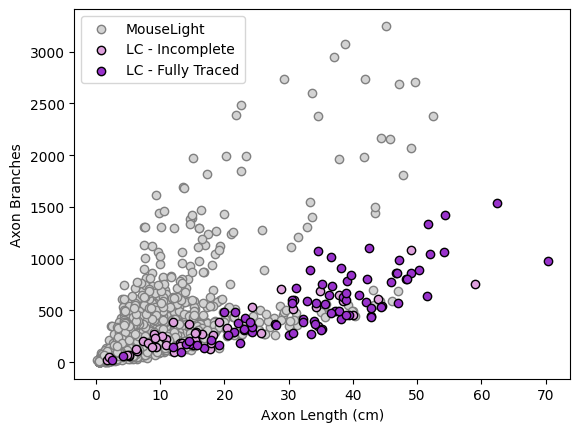

In [14]:
# Plot axon length vs branching
# Neurons with spinal cord projections from brains that do not have complete spinal cord may be incomplete.
incompleteMorphology = featureDF["isSpinalProjecting"] & ~featureDF["completeSC"]

plt.figure()

# Plot Mouselight data for reference
sns.scatterplot(ml_featureDF,x = "Axon Length (cm)", y = "Axon Branches", edgecolor = "gray", facecolor = "lightgray", linewidth = 1)

# Plot LC reconstructions
sns.scatterplot(featureDF[incompleteMorphology],x = "Axon Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "Plum", linewidth = 1)
sns.scatterplot(featureDF[~incompleteMorphology],x = "Axon Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "DarkOrchid", linewidth = 1)
plt.legend(["MouseLight","LC - Incomplete","LC - Fully Traced"])

# # Add regression lines
# sns.regplot(ml_featureDF,x = "Axon Length (cm)", y = "Axon Branches", color = "black", scatter = False)
# sns.regplot(featureDF,x = "Axon Length (cm)", y = "Axon Branches", color = "DarkOrchid", scatter = False)
plt.savefig(SAVE_DIR.joinpath(f"figure s4 - LC and Mouselight axon length vs branch count.svg"),dpi=300,bbox_inches='tight')

### Cortical Flatmap

In [15]:
# Get flatmap area boundaries
bf_boundary_finder = ccfproj.BoundaryFinder(
    projected_atlas_file="../data/mouse_ccf_cortical_coordinates_2017/ccf_streamlines_assets/master_updated/flatmap_dorsal.nrrd",
    labels_file="../data/mouse_ccf_cortical_coordinates_2017/ccf_streamlines_assets/master_updated/labelDescription_ITKSNAPColor.txt",
)

bf_right_boundaries = bf_boundary_finder.region_boundaries(
    hemisphere='right',
    view_space_for_other_hemisphere='flatmap_dorsal',
)


In [16]:
# Compute volume of each cortical area
volDict = {}
for name in bf_right_boundaries.keys():
    x = utils.get_mesh_from_id(acronym_to_id[name], BASE_DIR)
    volDict[name] = compute_mesh_volume(x[0],x[2])

# Convert to a dataframe of cubic centimeters
roi_volumes = pd.Series(volDict) / 1e11

In [17]:
# Compute length for cortical areas
cortical_lengthDF = clustering.build_length_df(dataDF,graphs,BASE_DIR,normalize_df=False,roi_version=4).drop(columns = "Other")
cortical_lengthDF = cortical_lengthDF[(cortical_lengthDF > 0).any(axis = 1)]
cortical_lengthDF.head(3)

,AUDv,SSs,ECT,VISp,VISC,GU,VISpm,MOs,VISl,FRP,...,ACAd,ACAv,SSp-ll,SSp-n,SSp-un,SSp-bfd,SSp-tr,VISa,VISrl,VISam
N023-648434,2127.511853,4618.963084,16838.008953,21714.986928,9025.407817,5396.905573,1335.786386,7969.816871,3439.312074,1984.479759,...,799.520516,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
N004-648434,2668.302346,10241.258698,2473.426944,0.000000,636.634505,987.187015,0.000000,60509.063434,0.000000,2379.060960,...,12055.400178,5636.572123,1362.642522,2183.108310,652.573150,0.000000,0.000000,0.000000,0.000000,0.000000
N011-648434,512.227488,2681.097130,309.912204,1822.126728,0.000000,2247.118518,4276.217492,35697.216450,0.000000,0.000000,...,12747.120971,7495.034480,2814.772168,91.851049,2448.435165,15764.318393,1431.220391,1145.732356,2390.486656,104.661269


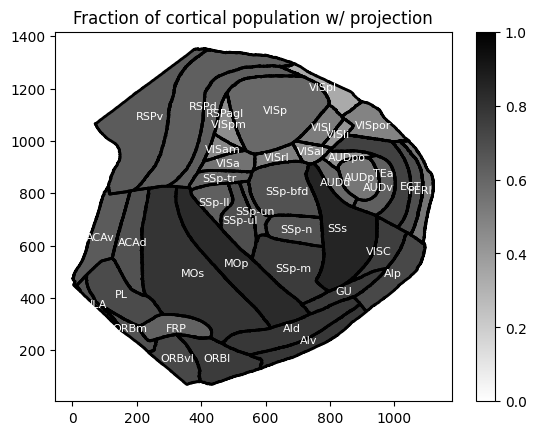

In [18]:
# Plot the fraction of the cortically projecting LC population innervating each area
values = np.sum(cortical_lengthDF.divide(cortical_lengthDF.sum(axis=1), axis = 0) > 0, axis = 0) / len(cortical_lengthDF)
norm = mcolors.Normalize(vmin=0, vmax=1)  # Normalize values
cmap = sns.color_palette("gray_r", as_cmap=True)

# Make plot
fig, ax = plt.subplots()

for area, boundary_coords in bf_right_boundaries.items():
    color = cmap(norm(values[area]))
    plt.fill(*boundary_coords.T, color = color)
    plt.plot(*boundary_coords.T, color = 'k', lw= 2)
    plt.text(np.mean(boundary_coords[:,0]),np.mean(boundary_coords[:,1]),area, horizontalalignment = "center", verticalalignment = "center", fontsize = 8, color = 'white')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Needed only for colorbar
# plt.colorbar(sm, ax = ax, label='Fraction of cortical population')
plt.colorbar(sm, ax = ax)
plt.title("Fraction of cortical population w/ projection")
plt.savefig(SAVE_DIR.joinpath(f"figure s4 - fractional of cortically projecting population with length in given area.svg"),dpi=300,bbox_inches='tight',transparent=True)

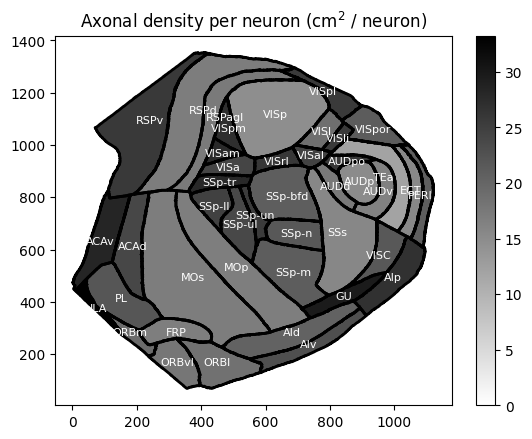

In [19]:
# Plot the per neuron density in each cortical area
roi_length_per_neuron = cortical_lengthDF[cortical_lengthDF != 0].mean(axis = 0) / 1e4
roi_density_per_neuron = roi_length_per_neuron / roi_volumes
values = roi_density_per_neuron.values  # values to map to colors
norm = mcolors.Normalize(vmin=0, vmax=values.max())  # Normalize values
cmap = sns.color_palette("gray_r", as_cmap=True)

# Make plot
fig, ax = plt.subplots()

for area, boundary_coords in bf_right_boundaries.items():
    color = cmap(norm(roi_density_per_neuron[area]))
    plt.fill(*boundary_coords.T, color = color)
    plt.plot(*boundary_coords.T, color = 'k', lw= 2)
    txtColor = 'white'
    plt.text(np.mean(boundary_coords[:,0]),np.mean(boundary_coords[:,1]),area, horizontalalignment = "center", verticalalignment = "center", fontsize = 8, color = txtColor)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Needed only for colorbar
plt.colorbar(sm, ax = ax)
plt.title("Axonal density per neuron (cm$^2$ / neuron)")
plt.savefig(SAVE_DIR.joinpath(f"figure s4 - cortical area axonal density per neuron.svg"),dpi=300,bbox_inches='tight',transparent=True)

### Compute correlation matrices

In [20]:
# Compute correlation between pairs of cortical areas
corrMatrix = cortical_lengthDF.corr(method = "spearman")

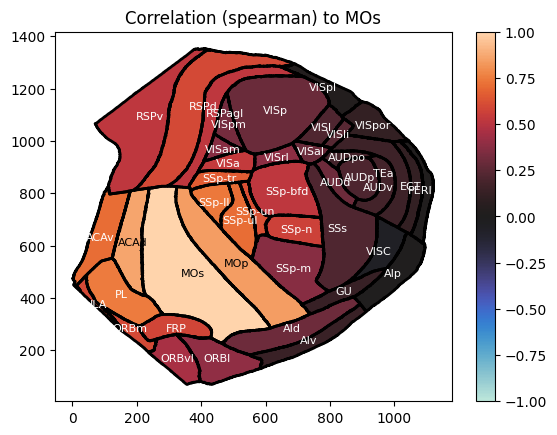

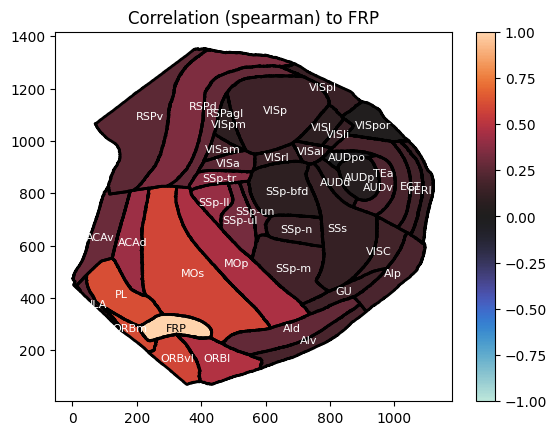

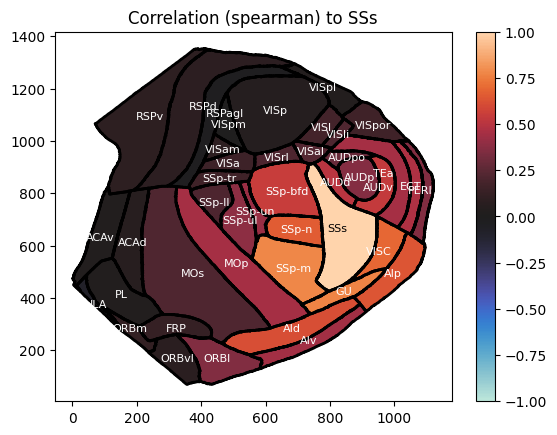

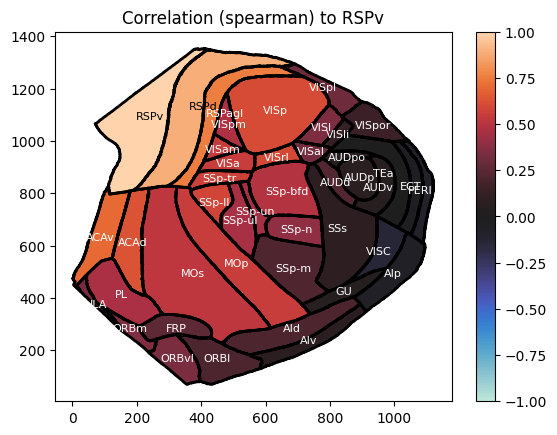

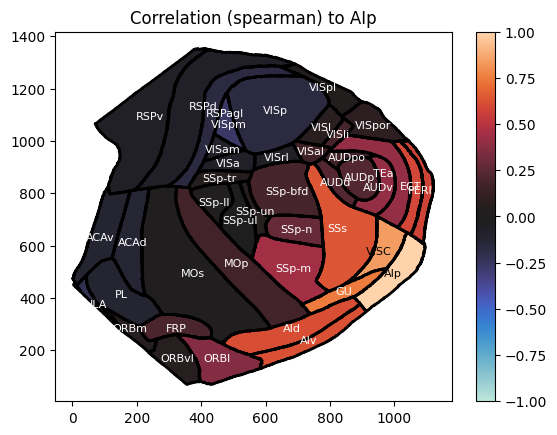

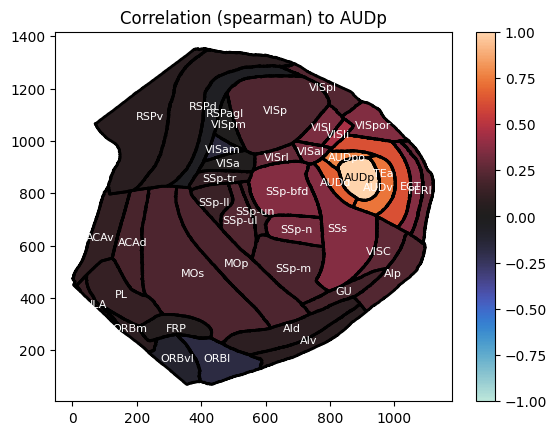

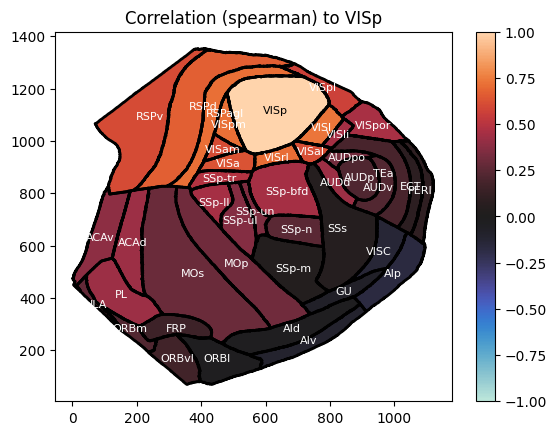

In [21]:
# Normalize values
featureList = ["MOs","FRP","SSs","RSPv","AIp","AUDp",'VISp']

for feature in featureList:
    # plt.figure()
    dfCorrs = corrMatrix[feature]
    values = dfCorrs.values  # values to map to colors
    norm = mcolors.Normalize(vmin=-1, vmax=1)  # Normalize values
    # cmap = cm.coolwarm # Choose the colormap
    cmap = sns.color_palette("icefire", as_cmap=True)
    
    # Make plot
    fig, ax = plt.subplots()
    
    for area, boundary_coords in bf_right_boundaries.items():
        color = cmap(norm(dfCorrs[area]))
        plt.fill(*boundary_coords.T, color = color)
        plt.plot(*boundary_coords.T, color = 'k', lw= 2)
        if norm(dfCorrs[area]) > .9:
            txtColor = 'black'
        else:
            txtColor = 'white'
        plt.text(np.mean(boundary_coords[:,0]),np.mean(boundary_coords[:,1]),area, horizontalalignment = "center", verticalalignment = "center", fontsize = 8, color = txtColor)
    
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Needed only for colorbar
    plt.colorbar(sm, ax = ax)
    plt.title(f"Correlation (spearman) to {feature}")
    plt.savefig(SAVE_DIR.joinpath(f"figure s4 - flatmap plot of correlation (spearman) to {feature}.svg"),dpi=300,bbox_inches='tight',transparent=True)

In [22]:
# Compute centroid distance between cortical areas
centroidDict = {}
for name in bf_right_boundaries.keys():
    x = utils.get_mesh_from_id(acronym_to_id[name], BASE_DIR)
    centroidDict[name] = compute_mesh_centroid(x[0],x[2])

In [23]:
# Build distance / correlation dataframe
pairs = []
distances = []
correlations = []

# Get all unique pairs of keys from the centroids (or corr_df)
keys = list(centroidDict.keys())

for key1, key2 in combinations(keys, 2):
    # Compute Euclidean distance between centroids
    c1 = np.array(centroidDict[key1])
    c2 = np.array(centroidDict[key2])
    dist = np.linalg.norm(c1 - c2)

    # Get correlation value from corr_df (assuming symmetric)
    corr_val = corrMatrix.loc[key1, key2]

    pairs.append((key1, key2))
    distances.append(dist)
    correlations.append(corr_val)

# Create DataFrame for plotting / analysis
dfCorrDist = pd.DataFrame({
    'pair': pairs,
    'distance': distances,
    'correlation': correlations
})

dfCorrDist["distance"] = dfCorrDist["distance"] / 1e3 # convert to mm

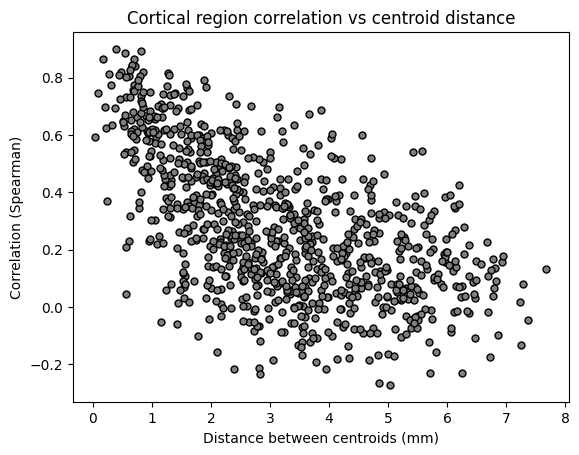

In [24]:
plt.plot(dfCorrDist['distance'], dfCorrDist['correlation'], 'o', markersize = 5, color = 'tab:gray', markeredgecolor = 'k')
plt.xlabel('Distance between centroids (mm)')
plt.ylabel('Correlation (Spearman)')
plt.title('Cortical region correlation vs centroid distance')
# plt.grid(True)
plt.savefig(SAVE_DIR.joinpath(f"figure s4 - cortical projection correlation (spearman) vs distance.svg"),dpi=300,bbox_inches='tight',transparent=True)

<Figure size 1920x1440 with 0 Axes>

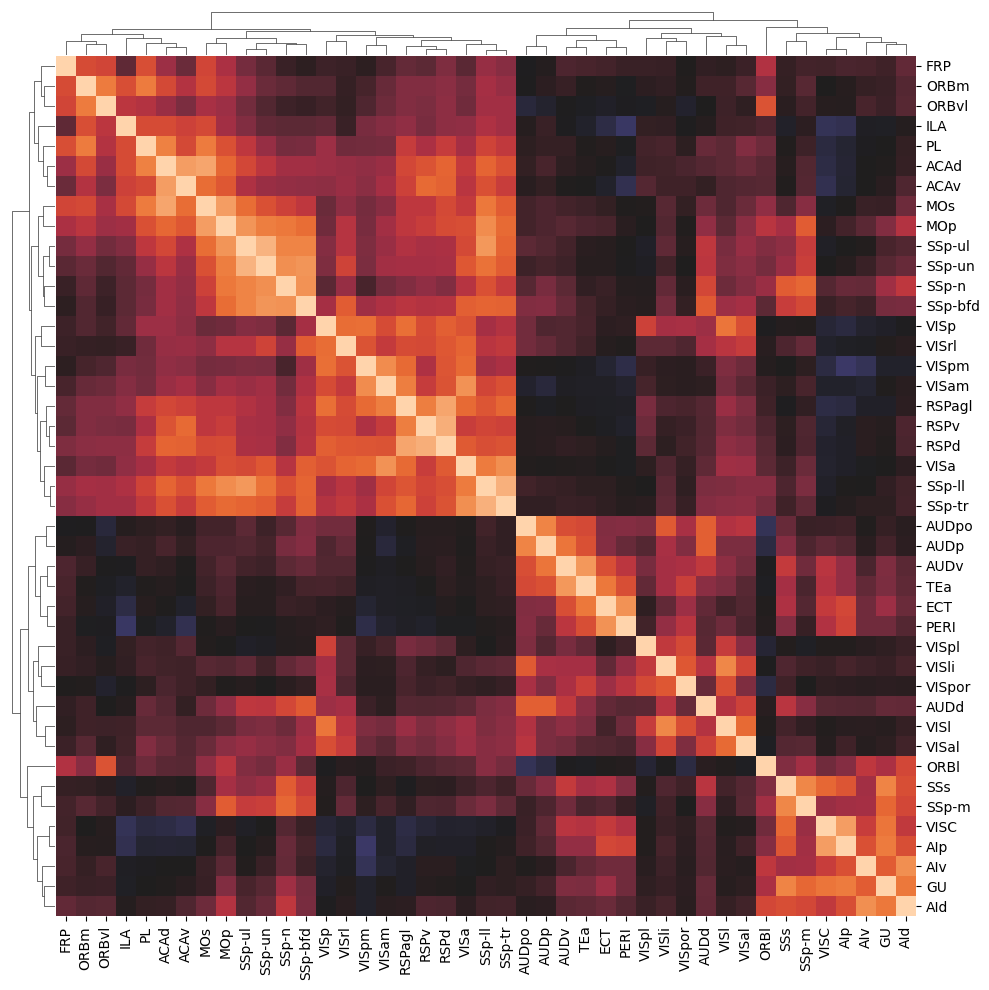

In [25]:
# Plot hierarchically clustered correlation matrix
plt.figure(dpi=300)
g = sns.clustermap(corrMatrix, xticklabels=True,yticklabels=True,  annot=False, fmt = '.2f', annot_kws={'size': 4}, cbar=False, dendrogram_ratio=.05, 
                   cmap = "icefire", center = 0, vmin = -1, vmax = 1)
# Remove colorbar axis completely if it still appears (still ranges from -1 to 1)
if g.cax is not None:
    g.cax.set_visible(False)
plt.yticks(fontsize=7);
plt.xticks(fontsize=7);
plt.savefig(SAVE_DIR.joinpath(f"figure s4 - correlation matrix (spearman) of hierarchically clustered cortical areas.svg"),dpi=300,bbox_inches='tight',transparent=True)

#### Cross functional correlation

In [26]:
sorted_rois = [
            "ACAd", "ACAv", "AId", "AIp", "AIv", "AUDd", "AUDp", "AUDpo", "AUDv", "ECT", "FRP", "GU", "ILA", "MOp", "MOs", "ORBl", "ORBm", "ORBvl", "PERI", "PL",
            "RSPagl", "RSPd", "RSPv", "SSp-bfd", "SSp-ll", "SSp-m", "SSp-n", "SSp-tr", "SSp-ul", "SSp-un", "SSs", "TEa", "VISal", "VISam", "VISC", "VISl", "VISp",
            "VISpl", "VISpm", "VISa", "VISli", "VISpor", "VISrl", "LING", "CENT", "CUL", "DEC", "FOTU", "PYR", "UVU", "NOD", "SIM", "AN", "PRM", "COPY", "PFL", "FL",
        ]

In [27]:
# Get length in cortical and cerebellar targets
ctx_and_cb_lengthDF = clustering.build_length_df(dataDF,graphs,BASE_DIR,normalize_df=False,roi_version=5)[sorted_rois]
# Subset to neurons that have at least some length in either cortex or cerebellum
ctx_or_cb_corrMatrix = ctx_and_cb_lengthDF[(ctx_and_cb_lengthDF > 0).any(axis = 1)].corr(method = "spearman")

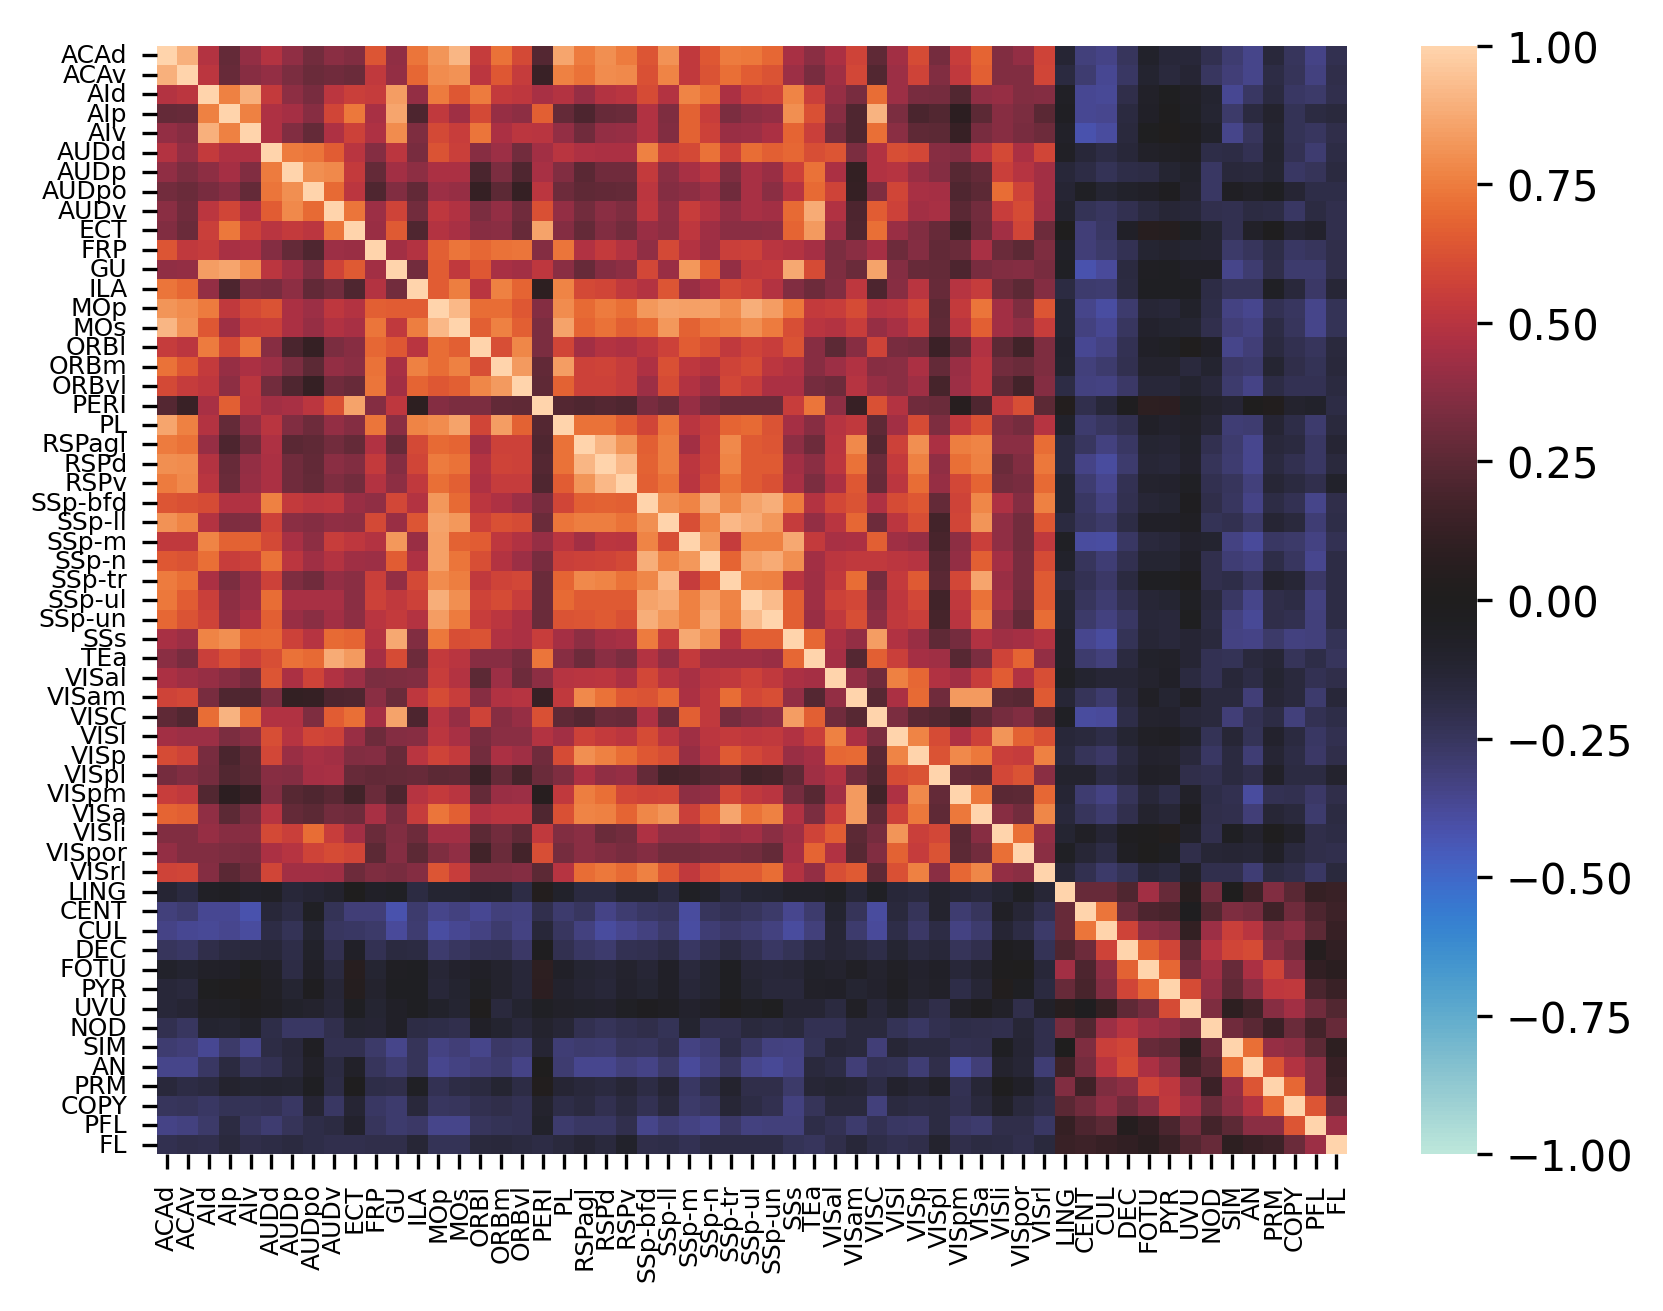

In [28]:
# Plot correlation between neurons with length in either cortex or cerebellum
plt.figure(dpi=300)
sns.heatmap(ctx_or_cb_corrMatrix , xticklabels=True,yticklabels=True,  annot=False, fmt = '.2f', annot_kws={'size': 4},  cmap='icefire', vmax = 1, vmin = -1, center = 0)
plt.yticks(fontsize=6);
plt.xticks(fontsize=6);
plt.savefig(SAVE_DIR.joinpath(f"figure s4 - correlation matrix (spearman) of cortical and cerebellar areas.svg"),dpi=300,bbox_inches='tight',transparent=True)